In [1]:
import argparse
import json
import logging
import csv

import os
import sys
sys.path.append("../..")
from pathlib import Path
from tqdm import tqdm

from monai.networks.nets import DiffusionModelUNet
import torch
from monai.config import print_config
from monai.utils import set_determinism
from monai.data import CacheDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import monai.transforms as transforms
import utils.custom_transforms as custom_transforms
import utils.simplex_ddpm as simplex_ddpm
import AnoDDPM.simplex as simplex

import numpy as np


import matplotlib.pyplot as plt

In [2]:
DEVICE_TYPE = "cuda:0"
device = torch.device(DEVICE_TYPE)

set_determinism(0)

#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [3]:

IMAGE_SIZE = 128

torch.backends.cudnn.benchmark = True
torch.set_num_threads(torch.get_num_threads())
torch.autograd.set_detect_anomaly(False)

In [19]:

batch_size = 10
num_workers = 8


# transforms
test_transforms = transforms.Compose(
    [
        transforms.LoadImage(image_only=True),
        transforms.EnsureChannelFirst(),
        custom_transforms.Get2DSlice(axis=2),
        transforms.ResizeWithPadOrCrop(spatial_size=(IMAGE_SIZE, IMAGE_SIZE)),
        custom_transforms.ScaleIntensityFromHistogramPeak(target_value=1000.0),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=3000.0, b_min=0.0, b_max=1.0, clip=True),
        custom_transforms.SetBackgroundToZero(),
        #transforms.EnsureType(device=device, track_meta=False)
    ]
)


#### ISLES ADC lesion images

In [20]:
large_group = ['sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.nii.gz', 'sub-strokecase0066_ses-0001_msk.nii.gz', 'sub-strokecase0081_ses-0001_msk.nii.gz', 'sub-strokecase0083_ses-0001_msk.nii.gz', 'sub-strokecase0087_ses-0001_msk.nii.gz', 'sub-strokecase0091_ses-0001_msk.nii.gz', 'sub-strokecase0123_ses-0001_msk.nii.gz', 'sub-strokecase0161_ses-0001_msk.nii.gz', 'sub-strokecase0162_ses-0001_msk.nii.gz', 'sub-strokecase0171_ses-0001_msk.nii.gz', 'sub-strokecase0176_ses-0001_msk.nii.gz', 'sub-strokecase0201_ses-0001_msk.nii.gz', 'sub-strokecase0211_ses-0001_msk.nii.gz', 'sub-strokecase0222_ses-0001_msk.nii.gz', 'sub-strokecase0223_ses-0001_msk.nii.gz', 'sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.nii.gz', 'sub-strokecase0066_ses-0001_msk.nii.gz', 'sub-strokecase0081_ses-0001_msk.nii.gz', 'sub-strokecase0083_ses-0001_msk.nii.gz', 'sub-strokecase0087_ses-0001_msk.nii.gz', 'sub-strokecase0091_ses-0001_msk.nii.gz', 'sub-strokecase0123_ses-0001_msk.nii.gz', 'sub-strokecase0161_ses-0001_msk.nii.gz', 'sub-strokecase0162_ses-0001_msk.nii.gz', 'sub-strokecase0171_ses-0001_msk.nii.gz', 'sub-strokecase0176_ses-0001_msk.nii.gz', 'sub-strokecase0201_ses-0001_msk.nii.gz', 'sub-strokecase0211_ses-0001_msk.nii.gz', 'sub-strokecase0222_ses-0001_msk.nii.gz', 'sub-strokecase0223_ses-0001_msk.nii.gz', 'sub-strokecase0230_ses-0001_msk.nii.gz', 'sub-strokecase0237_ses-0001_msk.nii.gz', 'sub-strokecase0240_ses-0001_msk.nii.gz', 'sub-strokecase0246_ses-0001_msk.nii.gz']
large_group_images = [ROOT_DIR+"datasets/final_adc_dataset_small/ISLES_registered/"+filename.replace("msk", "adc") for filename in large_group]

test_anomaly_large_ds = CacheDataset(data=large_group_images, transform=test_transforms)

test_anomaly_large_loader = DataLoader(
        test_anomaly_large_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
    )

Loading dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:05<00:00,  8.35it/s]


In [21]:
model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(32, 64, 64, 64),
    attention_levels=(False, False, True, True),
    num_head_channels=8
)
model.to(device)

model_path = ROOT_DIR+"AnoDiffExperiments/experiment_1/exp_1_0/models/exp_1_0_best_model.pth"
model.load_state_dict(torch.load(model_path, map_location=DEVICE_TYPE))

model.eval()



DiffusionModelUNet(
  (conv_in): Convolution(
    (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (time_embed): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock(
      (resnets): ModuleList(
        (0-1): 2 x DiffusionUNetResnetBlock(
          (norm1): GroupNorm(32, 32, eps=1e-06, affine=True)
          (nonlinearity): SiLU()
          (conv1): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (time_emb_proj): Linear(in_features=128, out_features=32, bias=True)
          (norm2): GroupNorm(32, 32, eps=1e-06, affine=True)
          (conv2): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (skip_connection): Identity()
        )
      )
      (downsampler): Diffus

In [12]:
infer_scheduler = simplex_ddpm.SimplexDDPMScheduler(num_train_timesteps=1000, schedule="cosine")

In [13]:
@torch.no_grad()
def my_sample(image, infer_scheduler, timesteps=100, return_intermediates=False):
    
    simplexObj = simplex.Simplex_CLASS()

    noise = simplex_ddpm.generate_simplex_noise(simplexObj, image.shape).to(device)
    

    if timesteps >= infer_scheduler.num_train_timesteps:
        print(timesteps, "is too high. Setting to", infer_scheduler.num_train_timesteps-1)

    timesteps_list = torch.Tensor([timesteps for a in range(image.shape[0])]).to(image.device).long()

    image = infer_scheduler.add_noise(image, noise, timesteps_list).to(device) #TODO


    intermediates = []
    intermediates_step = 20

            
    for t in range(timesteps, 0, -1): # va de timesteps à 0
        
        model_output = model(
            image, timesteps=torch.Tensor((t,)).to(device), context=None
        )
        #print(model_output.shape)
        
        image, _ = infer_scheduler.step(model_output, t, image)
      
        if (t== timesteps-1 or t%intermediates_step == 0) and return_intermediates:
            intermediates.append(image)

    if return_intermediates:
        return image, intermediates
    else:
        return image

In [22]:
batch = next(iter(test_anomaly_large_loader))
batch = batch.to(device)

image, intermediates = my_sample(batch, infer_scheduler, timesteps=200, return_intermediates=True)

Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/util.py", line 292, in _run_finalizers
    finalizer()
    ~~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/util.py", line 216, in __call__
    res = self._callback(*self._args, **self._kwargs)
  File "/usr/lib/python3.13/multiprocessing/util.py", line 125, in _remove_temp_dir
    rmtree(tempdir)
    ~~~~~~^^^^^^^^^
  File "/usr/lib/python3.13/shutil.py", line 763, in rmtree
    _rmtree_safe_fd(stack, onexc)
    ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "/usr/lib/python3.13/shutil.py", line 707, in _rmtree_safe_fd
    onexc(func, path, err)
    ~~~~~^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.13/shutil.py", line 658, in _rmtree_safe_fd
    os.rmdir(name, dir_fd=dirfd)
    ~~~~~~~~^^^^^^^^^^^^^^^^^^^^
OSError: [Errno 39] Directory not empty: '/tmp/pymp-eagjibkf'


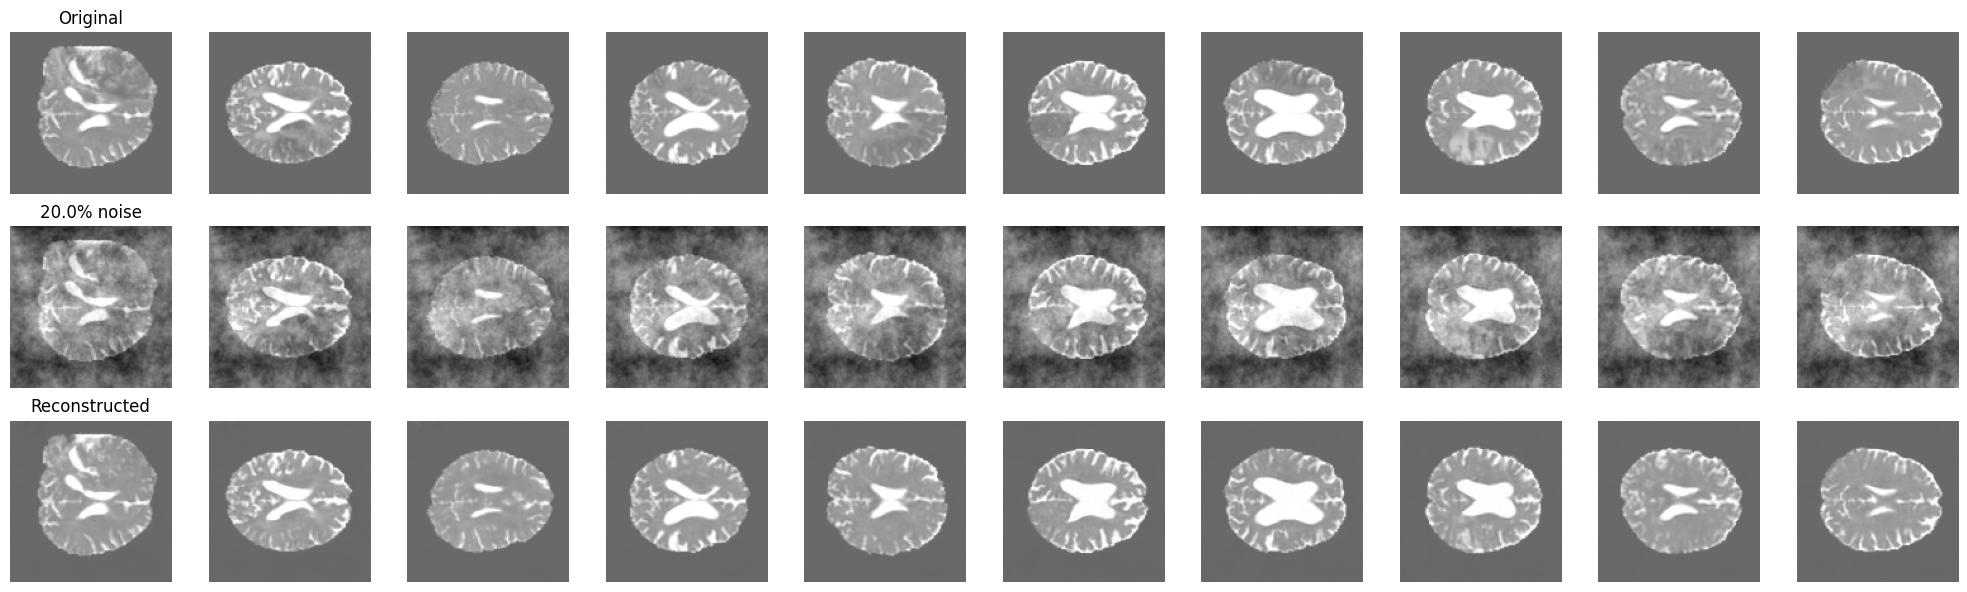

In [23]:
fig, axs = plt.subplots(3, batch.shape[0], figsize=(batch.shape[0]*2, 6))

for i in range(batch.shape[0]):
    # First row: original images
    axs[0, i].imshow(batch[i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[0, i].axis("off")
    if i == 0:
        axs[0, i].set_title("Original")

    # Second row: noisy images (intermediates[1])
    axs[1, i].imshow(intermediates[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[1, i].axis("off")
    if i == 0:
        axs[1, i].set_title(f"{(200/1000)*100}% noise")

    # Third row: reconstructed images
    axs[2, i].imshow(image[i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[2, i].axis("off")
    if i == 0:
        axs[2, i].set_title("Reconstructed")

plt.tight_layout()
plt.show()

#### ISLES FLAIR lesion images

In [5]:
model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(128, 128, 256, 256),
    attention_levels=(False, True, True, True),
    num_head_channels=[0, 128, 128, 256]
)
model.to(device)

model_path = ROOT_DIR+"AnoDiffExperiments/experiment_0/exp_0_0/models/exp_0_0_best_model.pth"
model.load_state_dict(torch.load(model_path, map_location=DEVICE_TYPE))

model.eval()



DiffusionModelUNet(
  (conv_in): Convolution(
    (conv): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (time_embed): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): SiLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock(
      (resnets): ModuleList(
        (0-1): 2 x DiffusionUNetResnetBlock(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (nonlinearity): SiLU()
          (conv1): Convolution(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv2): Convolution(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (skip_connection): Identity()
        )
      )
      (downsampler

In [6]:
large_group = ['sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.nii.gz', 'sub-strokecase0066_ses-0001_msk.nii.gz', 'sub-strokecase0081_ses-0001_msk.nii.gz', 'sub-strokecase0083_ses-0001_msk.nii.gz', 'sub-strokecase0087_ses-0001_msk.nii.gz', 'sub-strokecase0091_ses-0001_msk.nii.gz', 'sub-strokecase0123_ses-0001_msk.nii.gz', 'sub-strokecase0161_ses-0001_msk.nii.gz', 'sub-strokecase0162_ses-0001_msk.nii.gz', 'sub-strokecase0171_ses-0001_msk.nii.gz', 'sub-strokecase0176_ses-0001_msk.nii.gz', 'sub-strokecase0201_ses-0001_msk.nii.gz', 'sub-strokecase0211_ses-0001_msk.nii.gz', 'sub-strokecase0222_ses-0001_msk.nii.gz', 'sub-strokecase0223_ses-0001_msk.nii.gz', 'sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.nii.gz', 'sub-strokecase0066_ses-0001_msk.nii.gz', 'sub-strokecase0081_ses-0001_msk.nii.gz', 'sub-strokecase0083_ses-0001_msk.nii.gz', 'sub-strokecase0087_ses-0001_msk.nii.gz', 'sub-strokecase0091_ses-0001_msk.nii.gz', 'sub-strokecase0123_ses-0001_msk.nii.gz', 'sub-strokecase0161_ses-0001_msk.nii.gz', 'sub-strokecase0162_ses-0001_msk.nii.gz', 'sub-strokecase0171_ses-0001_msk.nii.gz', 'sub-strokecase0176_ses-0001_msk.nii.gz', 'sub-strokecase0201_ses-0001_msk.nii.gz', 'sub-strokecase0211_ses-0001_msk.nii.gz', 'sub-strokecase0222_ses-0001_msk.nii.gz', 'sub-strokecase0223_ses-0001_msk.nii.gz', 'sub-strokecase0230_ses-0001_msk.nii.gz', 'sub-strokecase0237_ses-0001_msk.nii.gz', 'sub-strokecase0240_ses-0001_msk.nii.gz', 'sub-strokecase0246_ses-0001_msk.nii.gz']
large_group_images_flair = [ROOT_DIR+"datasets/final_flair_dataset_small/isles_registered/"+filename.replace("msk", "FLAIR") for filename in large_group]

test_anomaly_large_flair_ds = CacheDataset(data=large_group_images_flair, transform=test_transforms)

test_anomaly_large_flair_loader = DataLoader(
        test_anomaly_large_flair_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
    )

Loading dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:05<00:00,  8.06it/s]


In [17]:
batch_flair = next(iter(test_anomaly_large_flair_loader))
batch_flair = batch_flair.to(device)

image_flair_35, intermediates_flair_35 = my_sample(batch_flair, infer_scheduler, timesteps=350, return_intermediates=True)

image_flair_30, intermediates_flair_30 = my_sample(batch_flair, infer_scheduler, timesteps=300, return_intermediates=True)

image_flair_25, intermediates_flair_25 = my_sample(batch_flair, infer_scheduler, timesteps=250, return_intermediates=True)

image_flair_20, intermediates_flair_20 = my_sample(batch_flair, infer_scheduler, timesteps=200, return_intermediates=True)

image_flair_15, intermediates_flair_15 = my_sample(batch_flair, infer_scheduler, timesteps=150, return_intermediates=True)

image_flair_10, intermediates_flair_10 = my_sample(batch_flair, infer_scheduler, timesteps=100, return_intermediates=True)

image_flair_5, intermediates_flair_5 = my_sample(batch_flair, infer_scheduler, timesteps=50, return_intermediates=True)

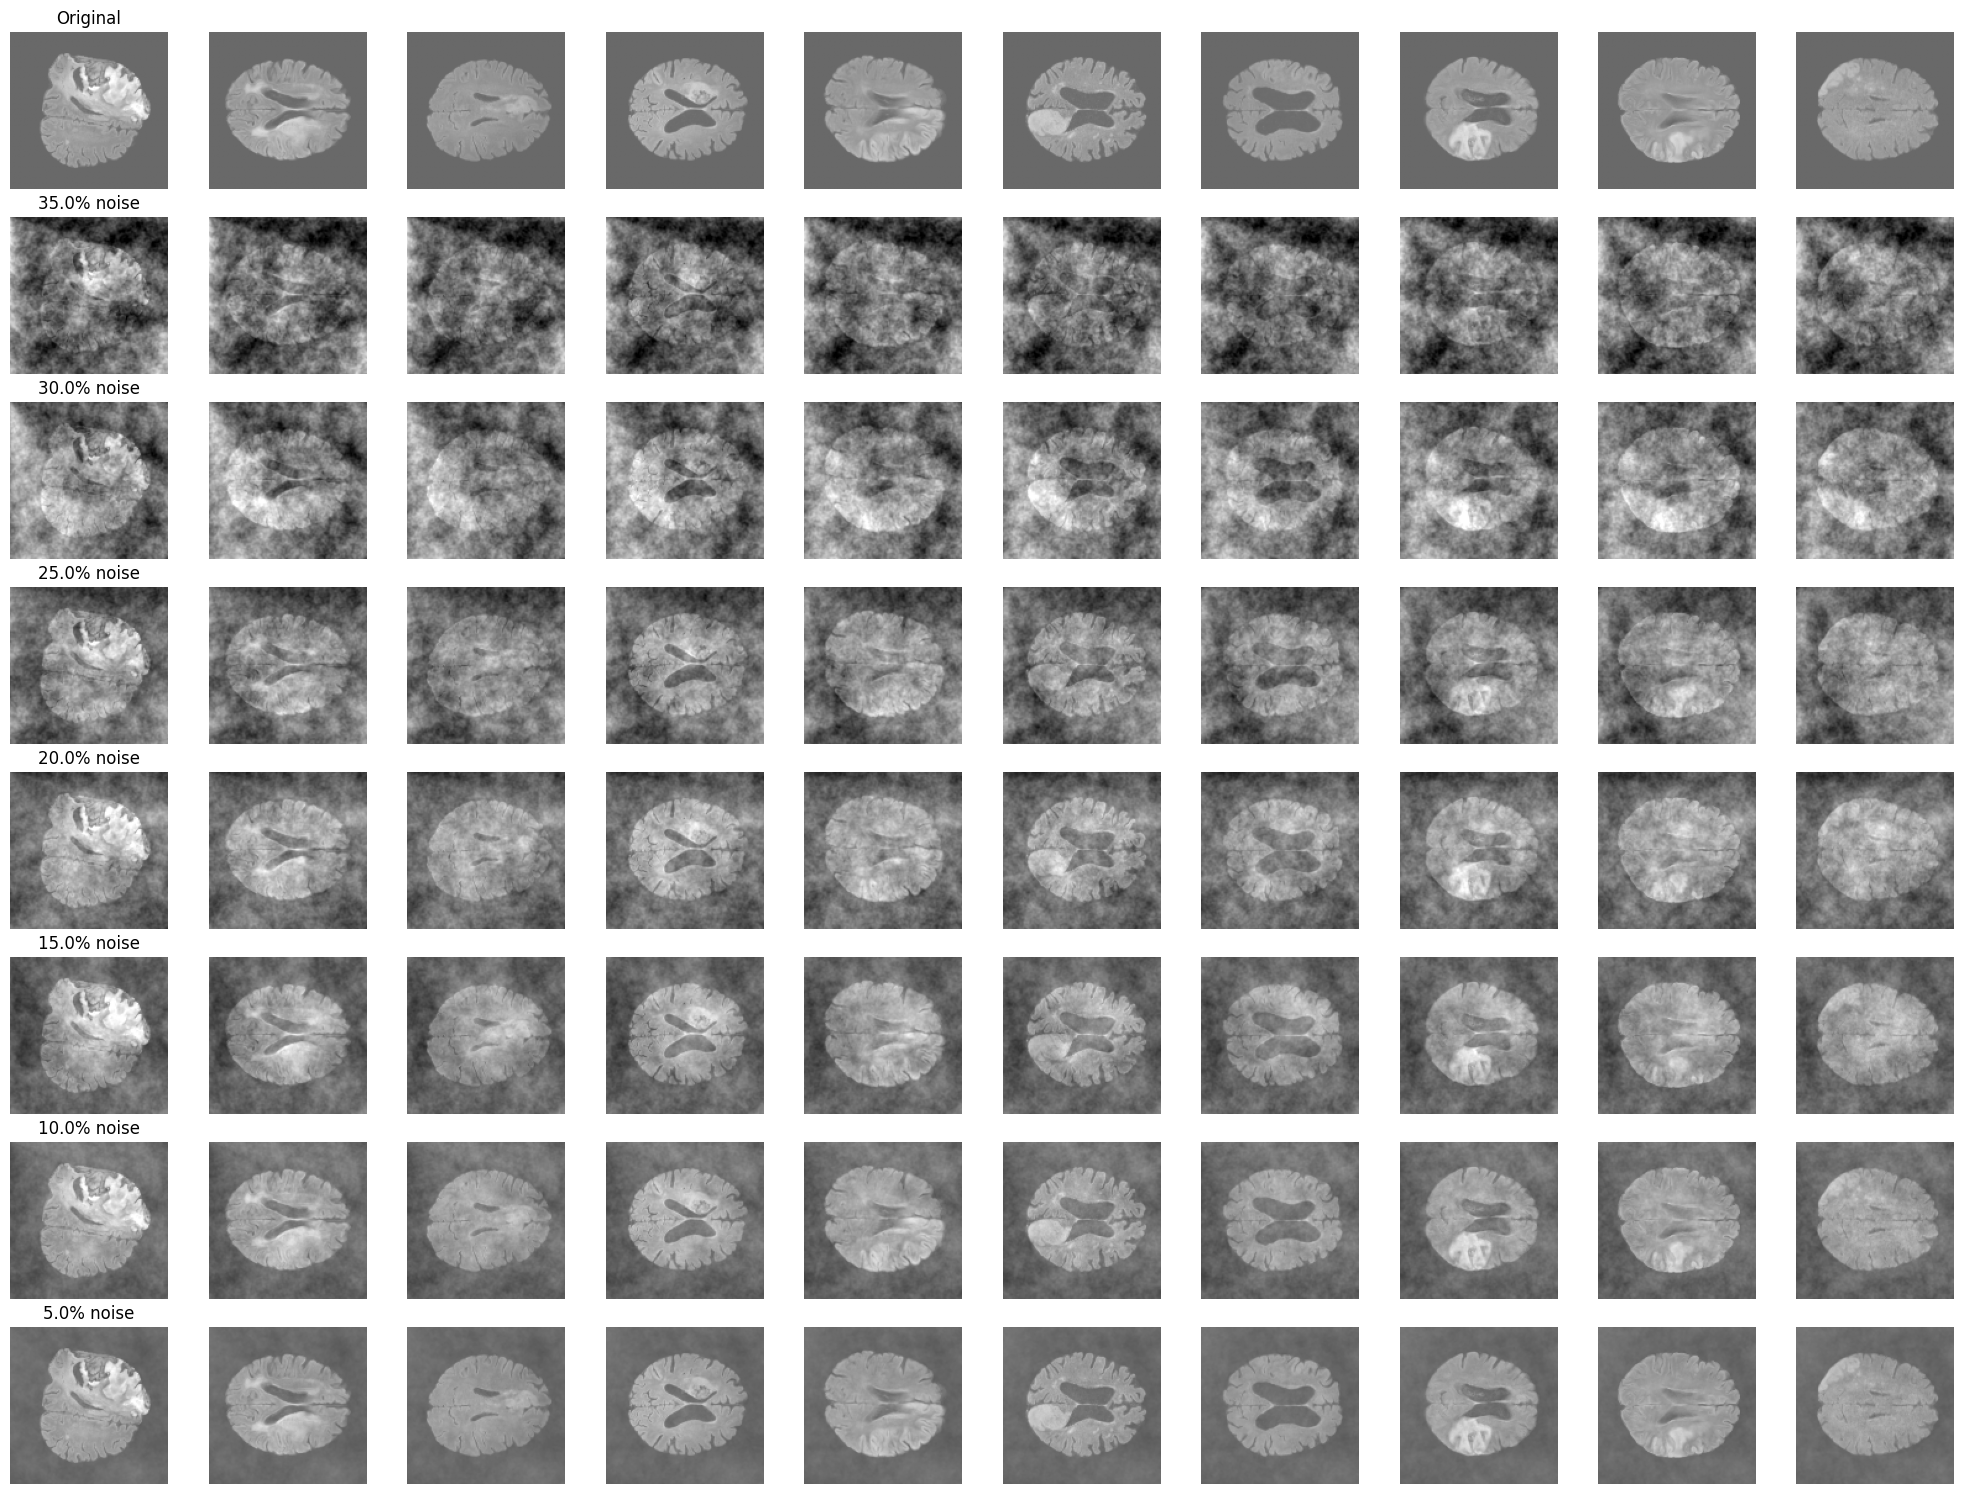

In [18]:
fig, axs = plt.subplots(8, batch_flair.shape[0], figsize=(batch_flair.shape[0]*2, 15))
plt.tight_layout()

for i in range(batch_flair.shape[0]):
    # First row: original images
    axs[0, i].imshow(batch_flair[i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[0, i].axis("off")
    if i == 0:
        axs[0, i].set_title("Original")

    # Second row: noisy images (intermediates[1])
    axs[1, i].imshow(intermediates_flair_35[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[1, i].axis("off")
    if i == 0:
        axs[1, i].set_title(f"{(350/1000)*100}% noise")

    # Second row: noisy images (intermediates[1])
    axs[2, i].imshow(intermediates_flair_30[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[2, i].axis("off")
    if i == 0:
        axs[2, i].set_title(f"{(300/1000)*100}% noise")

    # Second row: noisy images (intermediates[1])
    axs[3, i].imshow(intermediates_flair_25[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[3, i].axis("off")
    if i == 0:
        axs[3, i].set_title(f"{(250/1000)*100}% noise")

    # Second row: noisy images (intermediates[1])
    axs[4, i].imshow(intermediates_flair_20[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[4, i].axis("off")
    if i == 0:
        axs[4, i].set_title(f"{(200/1000)*100}% noise")

    # Second row: noisy images (intermediates[1])
    axs[5, i].imshow(intermediates_flair_15[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[5, i].axis("off")
    if i == 0:
        axs[5, i].set_title(f"{(150/1000)*100}% noise")

    # Second row: noisy images (intermediates[1])
    axs[6, i].imshow(intermediates_flair_10[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[6, i].axis("off")
    if i == 0:
        axs[6, i].set_title(f"{(100/1000)*100}% noise")

    # Second row: noisy images (intermediates[1])
    axs[7, i].imshow(intermediates_flair_5[1][i, 0].cpu(), vmin=-0.7, vmax=1, cmap="gray")
    axs[7, i].axis("off")
    if i == 0:
        axs[7, i].set_title(f"{(50/1000)*100}% noise")


plt.tight_layout()
plt.show()